# Métodos de Buscas em Labirinto


1. Busca em Largura — **BFS**;
2. Busca em Profundidade — **DFS**;
3. Busca de Custo Uniforme — **UCS**;
4. Busca Gulosa pela Melhor Escolha — **Greedy Best-First Search**;
5. Busca **A\*** (Clássica)
6. Busca **Weighted A\***;
7. Busca **IDA\*** — Iterative Deepening A\*.
8. **Hill-Climbing\*** (Otimização de Rota com Pontos "C")
9. **Simulated Annealing\*** (Otimização de Rota com Pontos "C")
10. Busca **Online\***

## 1. Carregar o arquivo `.txt` do labirinto

Execute a célula abaixo e selecione o arquivo `.txt` do labirinto. No Google Colab, será aberta a janela de upload. Fora do Colab, a célula pedirá o caminho local do arquivo.


In [18]:
from pathlib import Path

try:
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise ValueError('Nenhum arquivo foi carregado.')
    NOME_ARQUIVO_LABIRINTO = next(iter(uploaded.keys()))
except Exception as exc:
    print('Upload via Colab não disponível ou cancelado.')
    print('Informe manualmente o caminho do arquivo .txt do labirinto.')
    NOME_ARQUIVO_LABIRINTO = input('Caminho do arquivo: ').strip()

if not Path(NOME_ARQUIVO_LABIRINTO).exists():
    raise FileNotFoundError(f'Arquivo não encontrado: {NOME_ARQUIVO_LABIRINTO}')

print(f'Arquivo carregado: {NOME_ARQUIVO_LABIRINTO}')


Upload via Colab não disponível ou cancelado.
Informe manualmente o caminho do arquivo .txt do labirinto.
Arquivo carregado: /home/emerson/Downloads/Agente-Inteligente-em-Labirinto/labirintos/lab_coleta_medio.txt


Definições utilizadas neste notebook:

- **nó explorado**: nó retirado da fronteira, pilha, fila ou visitado pela recursão do IDA* para análise;
- **nó expandido**: nó cujos sucessores foram efetivamente gerados;
- **tamanho do caminho**: número de movimentos da solução final, isto é, o número de arestas entre `A` e `B`;
- **custo do caminho**: soma dos custos das ações executadas ao longo da solução encontrada;
- **fronteira**: conjunto de nós gerados, mas ainda não explorados pelo algoritmo;
- **tempo de execução**: tempo total gasto pelo algoritmo para encontrar uma solução ou concluir que não existe solução;
- **tamanho máximo da fronteira**: maior quantidade de nós simultaneamente armazenados na fronteira durante a execução;
- **estado**: posição do agente no labirinto representada por uma tupla `(linha, coluna)`;
- **ação**: movimento executado pelo agente (`up`, `down`, `left`, `right`);
- **heurística**: estimativa do custo restante até o objetivo calculada pela distância de Manhattan;
- **gráficos**: geração de gráficos comparativos e individuais para análise do desempenho dos algoritmos.

In [19]:
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Set
from collections import deque
import heapq
import itertools
import math
import time
import matplotlib.pyplot as plt

Estado = Tuple[int, int]

@dataclass
class No:
    estado: Estado
    pai: Optional['No'] = None
    acao: Optional[str] = None
    g: float = 0.0

@dataclass
class ResultadoBusca:
    algoritmo: str
    encontrado: bool
    caminho: List[Estado]
    acoes: List[str]
    nos_explorados: int
    nos_expandidos: int
    estados_explorados: List[Estado]
    tempo_execucao: float = 0.0
    tamanho_max_fronteira: int = 0
    custo_caminho: float = 0.0

    @property
    def tamanho_caminho(self) -> Optional[int]:
        return len(self.acoes) if self.encontrado else None

class LabirintoBusca:
    def __init__(self, filename: str):
        with open(filename, encoding='utf-8') as f:
            contents = f.read()

        if contents.count('A') != 1:
            raise ValueError('O labirinto deve ter exatamente um ponto inicial A.')
        if contents.count('B') != 1:
            raise ValueError('O labirinto deve ter exatamente um objetivo B.')

        linhas = contents.splitlines()
        self.altura = len(linhas)
        self.largura = max(len(linha) for linha in linhas)
        self.paredes = []
        self.pontos_coleta = []

        for i in range(self.altura):
            row = []
            for j in range(self.largura):
                char = linhas[i][j] if j < len(linhas[i]) else ' '
                if char == 'A':
                    self.inicio = (i, j)
                    row.append(False)
                elif char == 'B':
                    self.objetivo = (i, j)
                    row.append(False)
                elif char == 'C':
                    self.pontos_coleta.append((i, j)) 
                    row.append(False)
                elif char == ' ':
                    row.append(False)
                else:
                    row.append(True)
            self.paredes.append(row)

    def vizinhos(self, estado: Estado):
        linha, coluna = estado
        candidatos = [
            ('up',    (linha - 1, coluna)),
            ('down',  (linha + 1, coluna)),
            ('left',  (linha, coluna - 1)),
            ('right', (linha, coluna + 1)),
        ]
        resultado = []
        for acao, (l, c) in candidatos:
            if 0 <= l < self.altura and 0 <= c < self.largura and not self.paredes[l][c]:
                resultado.append((acao, (l, c), 1.0))
        return resultado

    def h(self, estado: Estado) -> float:
        return abs(estado[0] - self.objetivo[0]) + abs(estado[1] - self.objetivo[1])

    @staticmethod
    def reconstruir(no: No):
        estados = []
        acoes = []
        atual = no
        while atual.pai is not None:
            estados.append(atual.estado)
            acoes.append(atual.acao)
            atual = atual.pai
        estados.reverse()
        acoes.reverse()
        return estados, acoes

    def busca_largura(self) -> ResultadoBusca:
        inicio_tempo = time.perf_counter()
        inicio = No(self.inicio)
        fronteira = deque([inicio])
        em_fronteira = {self.inicio}
        explorados: Set[Estado] = set()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0
        max_fronteira = 1

        while fronteira:
            max_fronteira = max(max_fronteira, len(fronteira))
            no = fronteira.popleft()
            em_fronteira.remove(no.estado)
            nos_explorados += 1
            ordem_explorados.append(no.estado)

            if no.estado == self.objetivo:
                caminho, acoes = self.reconstruir(no)
                tempo = time.perf_counter() - inicio_tempo
                return ResultadoBusca('BFS', True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, no.g)

            explorados.add(no.estado)
            nos_expandidos += 1

            for acao, estado, custo in self.vizinhos(no.estado):
                if estado not in explorados and estado not in em_fronteira:
                    filho = No(estado=estado, pai=no, acao=acao, g=no.g + custo)
                    fronteira.append(filho)
                    em_fronteira.add(estado)

        tempo = time.perf_counter() - inicio_tempo
        return ResultadoBusca('BFS', False, [], [], nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, 0.0)

    def busca_profundidade(self) -> ResultadoBusca:
        inicio_tempo = time.perf_counter()
        inicio = No(self.inicio)
        fronteira = [inicio]
        em_fronteira = {self.inicio}
        explorados: Set[Estado] = set()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0
        max_fronteira = 1

        while fronteira:
            max_fronteira = max(max_fronteira, len(fronteira))
            no = fronteira.pop()
            em_fronteira.remove(no.estado)
            nos_explorados += 1
            ordem_explorados.append(no.estado)

            if no.estado == self.objetivo:
                caminho, acoes = self.reconstruir(no)
                tempo = time.perf_counter() - inicio_tempo
                return ResultadoBusca('DFS', True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, no.g)

            explorados.add(no.estado)
            nos_expandidos += 1

            for acao, estado, custo in self.vizinhos(no.estado):
                if estado not in explorados and estado not in em_fronteira:
                    filho = No(estado=estado, pai=no, acao=acao, g=no.g + custo)
                    fronteira.append(filho)
                    em_fronteira.add(estado)

        tempo = time.perf_counter() - inicio_tempo
        return ResultadoBusca('DFS', False, [], [], nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, 0.0)

    def busca_prioridade(self, nome: str, funcao_prioridade) -> ResultadoBusca:
        inicio_tempo = time.perf_counter()
        contador = itertools.count()
        inicio = No(self.inicio, g=0.0)
        fronteira = []
        heapq.heappush(fronteira, (funcao_prioridade(inicio), next(contador), inicio))
        melhor_g: Dict[Estado, float] = {self.inicio: 0.0}
        fechados: Set[Estado] = set()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0
        max_fronteira = 1

        while fronteira:
            max_fronteira = max(max_fronteira, len(fronteira))
            _, _, no = heapq.heappop(fronteira)

            if no.estado in fechados:
                continue

            nos_explorados += 1
            ordem_explorados.append(no.estado)

            if no.estado == self.objetivo:
                caminho, acoes = self.reconstruir(no)
                tempo = time.perf_counter() - inicio_tempo
                return ResultadoBusca(nome, True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, no.g)

            fechados.add(no.estado)
            nos_expandidos += 1

            for acao, estado, custo in self.vizinhos(no.estado):
                novo_g = no.g + custo
                if estado in fechados:
                    continue
                if novo_g < melhor_g.get(estado, math.inf):
                    filho = No(estado=estado, pai=no, acao=acao, g=novo_g)
                    melhor_g[estado] = novo_g
                    heapq.heappush(fronteira, (funcao_prioridade(filho), next(contador), filho))

        tempo = time.perf_counter() - inicio_tempo
        return ResultadoBusca(nome, False, [], [], nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, 0.0)

    def busca_custo_uniforme(self) -> ResultadoBusca:
        return self.busca_prioridade('UCS', lambda no: no.g)

    def busca_gulosa(self) -> ResultadoBusca:
        return self.busca_prioridade('Gulosa', lambda no: self.h(no.estado))

    def busca_weighted_astar(self, peso: float = 2.0) -> ResultadoBusca:
        return self.busca_prioridade(f'WA* (w={peso})', lambda no: no.g + peso * self.h(no.estado))
    
    def busca_astar(self) -> ResultadoBusca:
        return self.busca_prioridade('A*', lambda no: no.g + self.h(no.estado))

    def busca_idastar(self) -> ResultadoBusca:
        inicio_tempo = time.perf_counter()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0
        limite = self.h(self.inicio)
        inicio = No(self.inicio, g=0.0)
        max_fronteira = 0

        def dfs_limitado(no: No, limite_atual: float, caminho_atual: Set[Estado]):
            nonlocal nos_explorados, nos_expandidos, ordem_explorados, max_fronteira
            max_fronteira = max(max_fronteira, len(caminho_atual))
            nos_explorados += 1
            ordem_explorados.append(no.estado)
            f = no.g + self.h(no.estado)

            if f > limite_atual:
                return f, None
            if no.estado == self.objetivo:
                return 'FOUND', no

            nos_expandidos += 1
            menor_proximo_limite = math.inf
            vizinhos_ordenados = sorted(
                self.vizinhos(no.estado),
                key=lambda item: no.g + item[2] + self.h(item[1])
            )

            for acao, estado, custo in vizinhos_ordenados:
                if estado in caminho_atual:
                    continue
                filho = No(estado=estado, pai=no, acao=acao, g=no.g + custo)
                caminho_atual.add(estado)
                temp, solucao = dfs_limitado(filho, limite_atual, caminho_atual)
                caminho_atual.remove(estado)

                if temp == 'FOUND':
                    return 'FOUND', solucao
                if temp < menor_proximo_limite:
                    menor_proximo_limite = temp

            return menor_proximo_limite, None

        while True:
            temp, solucao = dfs_limitado(inicio, limite, {self.inicio})
            if temp == 'FOUND':
                caminho, acoes = self.reconstruir(solucao)
                tempo = time.perf_counter() - inicio_tempo
                return ResultadoBusca('IDA*', True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, solucao.g)
            if temp == math.inf:
                tempo = time.perf_counter() - inicio_tempo
                return ResultadoBusca('IDA*', False, [], [], nos_explorados, nos_expandidos, ordem_explorados, tempo, max_fronteira, 0.0)
            limite = temp  

    def calcular_matriz_distancias(self) -> Dict[Tuple[Estado, Estado], float]:
        pontos = [self.inicio] + self.pontos_coleta + [self.objetivo]
        matriz_distancias = {}
        
        inicio_original = self.inicio
        objetivo_original = self.objetivo
        
        for p1 in pontos:
            for p2 in pontos:
                if p1 == p2:
                    matriz_distancias[(p1, p2)] = 0.0
                    continue
                if (p1, p2) in matriz_distancias:
                    continue
                
                self.inicio = p1
                self.objetivo = p2
                
                res = self.busca_astar()
                if res.encontrado:
                    matriz_distancias[(p1, p2)] = res.custo_caminho
                    matriz_distancias[(p2, p1)] = res.custo_caminho
                else:
                    matriz_distancias[(p1, p2)] = math.inf
                    matriz_distancias[(p2, p1)] = math.inf
                    
        self.inicio = inicio_original
        self.objetivo = objetivo_original
        return matriz_distancias

    def calcular_custo_total_rota(self, rota: List[Estado], matriz_distancias: dict) -> float:
        if not rota:
            return matriz_distancias.get((self.inicio, self.objetivo), math.inf)
            
        custo = matriz_distancias.get((self.inicio, rota[0]), math.inf)
        for i in range(len(rota) - 1):
            custo += matriz_distancias.get((rota[i], rota[i+1]), math.inf)
        custo += matriz_distancias.get((rota[-1], self.objetivo), math.inf)
        return custo

    def obter_vizinhos_busca_local(self, rota_atual: List[Estado], tipo_vizinhanca: str = 'swap') -> List[List[Estado]]:
        vizinhos = []
        n = len(rota_atual)
        
        if tipo_vizinhanca == 'swap':
            for i in range(n):
                for j in range(i + 1, n):
                    nova_rota = list(rota_atual)
                    nova_rota[i], nova_rota[j] = nova_rota[j], nova_rota[i]
                    vizinhos.append(nova_rota)
                    
        elif tipo_vizinhanca == 'inverse':
            for i in range(n):
                for j in range(i + 2, n + 1):
                    nova_rota = list(rota_atual)
                    nova_rota[i:j] = list(reversed(nova_rota[i:j]))
                    vizinhos.append(nova_rota)
                    
        return vizinhos

    def hill_climbing(self, tipo_vizinhanca: str = 'swap') -> Tuple[List[Estado], float, List[float], int]:
        import random
        matriz_distancias = self.calcular_matriz_distancias()
        
        if not self.pontos_coleta:
            return [], matriz_distancias.get((self.inicio, self.objetivo), 0.0), [0.0], 0

        estado_atual = list(self.pontos_coleta)
        random.shuffle(estado_atual)
        custo_atual = self.calcular_custo_total_rota(estado_atual, matriz_distancias)
        
        historico_custo = [custo_atual]
        iteracoes = 0
        
        while True:
            iteracoes += 1
            vizinhos = self.obter_vizinhos_busca_local(estado_atual, tipo_vizinhanca)
            melhor_vizinho = None
            melhor_custo_vizinho = custo_atual
            
            for vizinho in vizinhos:
                custo_viz = self.calcular_custo_total_rota(vizinho, matriz_distancias)
                if custo_viz < melhor_custo_vizinho:
                    melhor_custo_vizinho = custo_viz
                    melhor_vizinho = vizinho
            
            if melhor_custo_vizinho >= custo_atual:
                break
                
            estado_atual = melhor_vizinho
            custo_atual = melhor_custo_vizinho
            historico_custo.append(custo_atual)
            
        return estado_atual, custo_atual, historico_custo, iteracoes

    def simulated_annealing(self, temp_inicial: float = 1000.0, taxa_resfriamento: float = 0.95, 
                            max_iter: int = 1000, tipo_vizinhanca: str = 'swap') -> Tuple[List[Estado], float, List[float], int]:
        import random
        matriz_distancias = self.calcular_matriz_distancias()
        
        if not self.pontos_coleta:
            return [], matriz_distancias.get((self.inicio, self.objetivo), 0.0), [0.0], 0

        estado_atual = list(self.pontos_coleta)
        random.shuffle(estado_atual)
        custo_atual = self.calcular_custo_total_rota(estado_atual, matriz_distancias)
        
        melhor_estado = estado_atual
        melhor_custo = custo_atual
        
        T = temp_inicial
        historico_custo = [custo_atual]
        iteracoes = 0
        
        for iteracao in range(max_iter):
            iteracoes += 1
            if T < 1e-4:
                break
                
            vizinho_sorteado = list(estado_atual)
            n = len(vizinho_sorteado)
            
            if tipo_vizinhanca == 'swap':
                i, j = random.sample(range(n), 2)
                vizinho_sorteado[i], vizinho_sorteado[j] = vizinho_sorteado[j], vizinho_sorteado[i]
            elif tipo_vizinhanca == 'inverse':
                i, j = sorted(random.sample(range(n + 1), 2))
                vizinho_sorteado[i:j] = list(reversed(vizinho_sorteado[i:j]))
                
            custo_vizinho = self.calcular_custo_total_rota(vizinho_sorteado, matriz_distancias)
            
            delta_c = custo_vizinho - custo_atual
            
            if delta_c < 0 or random.random() < math.exp(-delta_c / T):
                estado_atual = vizinho_sorteado
                custo_atual = custo_vizinho
                
                if custo_atual < melhor_custo:
                    melhor_custo = custo_atual
                    melhor_estado = vizinho_sorteado
            
            historico_custo.append(melhor_custo)
            T *= taxa_resfriamento
            
        return melhor_estado, melhor_custo, historico_custo, iteracoes         


def plot_single_search_metrics_batch(resultado):
    if not resultado.encontrado:
        print("Gráfico não disponível: Solução não encontrada.")
        return

    nomes_metricas = ['Passos', 'Nós Expandidos', 'Fronteira Máx']
    valores_metricas = [
        resultado.tamanho_caminho, 
        resultado.nos_expandidos, 
        resultado.tamanho_max_fronteira
    ]
    
    plt.figure(figsize=(8, 5))
    cores = ['#4CAF50', '#F44336', '#2196F3']
    barras = plt.bar(nomes_metricas, valores_metricas, color=cores)
    
    plt.title(f'Métricas de Desempenho: {resultado.algoritmo}')
    plt.ylabel('Quantidade')
    
    for barra in barras:
        valor = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, valor + (max(valores_metricas)*0.02), 
                 str(valor), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_batch_comparison(lista_resultados):
    resultados_validos = [r for r in lista_resultados if r.encontrado]
    if not resultados_validos:
        return

    algoritmos = [r.algoritmo for r in resultados_validos]
    expandidos = [r.nos_expandidos for r in resultados_validos]
    tamanhos_caminho = [r.tamanho_caminho for r in resultados_validos]

    indices = range(len(algoritmos))
    largura = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar([i - largura/2 for i in indices], expandidos, width=largura, 
            label='Nós Expandidos (Esforço)', color='#F44336')
    plt.bar([i + largura/2 for i in indices], tamanhos_caminho, width=largura, 
            label='Passos (Qualidade)', color='#4CAF50')

    plt.title('Comparação: Esforço Computacional vs Qualidade da Solução')
    plt.xticks(indices, algoritmos)
    plt.ylabel('Quantidade')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_single_search_metrics_lines(resultado):
    if not resultado.encontrado:
        print("Gráfico não disponível: Solução não encontrada.")
        return

    nomes_metricas = ['Passos', 'Nós Expandidos', 'Fronteira Máx']
    valores_metricas = [
        resultado.tamanho_caminho, 
        resultado.nos_expandidos, 
        resultado.tamanho_max_fronteira
    ]
    
    plt.figure(figsize=(8, 5))
    plt.plot(nomes_metricas, valores_metricas, marker='o', linestyle='-', color='#2196F3', linewidth=2)
    
    plt.title(f'Métricas de Desempenho: {resultado.algoritmo}')
    plt.ylabel('Quantidade')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    for i, v in enumerate(valores_metricas):
        plt.text(i, v + (max(valores_metricas)*0.02), str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_lines_comparison(lista_resultados):
    resultados_validos = [r for r in lista_resultados if r.encontrado]
    if not resultados_validos:
        return

    algoritmos = [r.algoritmo for r in resultados_validos]
    expandidos = [r.nos_expandidos for r in resultados_validos]
    tamanhos_caminho = [r.tamanho_caminho for r in resultados_validos]

    plt.figure(figsize=(10, 6))
    
    plt.plot(algoritmos, expandidos, marker='s', linestyle='-', color='#F44336', label='Nós Expandidos (Esforço)')
    plt.plot(algoritmos, tamanhos_caminho, marker='o', linestyle='-', color='#4CAF50', label='Passos (Qualidade)')

    plt.title('Comparação: Esforço Computacional vs Qualidade da Solução')
    plt.ylabel('Quantidade')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

## 3. Funções para exibir o labirinto e a solução

A solução é marcada com `*`. Os nós explorados que não pertencem ao caminho final são marcados com `.`.


In [20]:
def imprimir_labirinto(lab: LabirintoBusca, resultado: Optional[ResultadoBusca] = None, mostrar_explorados: bool = True):
    caminho = set(resultado.caminho) if resultado and resultado.encontrado else set()
    explorados = set(resultado.estados_explorados) if resultado and mostrar_explorados else set()

    print()
    for i in range(lab.altura):
        for j in range(lab.largura):
            estado = (i, j)
            if lab.paredes[i][j]:
                print('█', end='')
            elif estado == lab.inicio:
                print('A', end='')
            elif estado == lab.objetivo:
                print('B', end='')
            elif estado in lab.pontos_coleta:
                if estado in caminho:
                    print('@', end='') 
                else:
                    print('C', end='') 
            elif estado in caminho:
                print('*', end='')
            elif estado in explorados:
                print('.', end='')
            else:
                print(' ', end='')
        print()
    print()


def imprimir_metricas(resultado: ResultadoBusca):
    print(f'Algoritmo executado: {resultado.algoritmo}')
    print(f'Solução encontrada: {"sim" if resultado.encontrado else "não"}')
    print(f'Nós explorados: {resultado.nos_explorados}')
    print(f'Nós expandidos: {resultado.nos_expandidos}')
    print(f'Tamanho do caminho encontrado: {resultado.tamanho_caminho}')

def plotar_convergencia_busca_local(historico_hc, historico_sa):
    plt.figure(figsize=(10, 5))
    plt.plot(historico_hc, label='Hill-Climbing', color='#F44336', marker='o', markevery=max(1, len(historico_hc)//5))
    plt.plot(historico_sa, label='Simulated Annealing', color='#2196F3', linestyle='--')
    plt.title('Curva de Convergência da Busca Local (Pontos de Coleta)', fontsize=14, fontweight='bold')
    plt.xlabel('Mutações / Alterações Aceitas na Sequência', fontsize=12)
    plt.ylabel('Melhor Custo da Rota (Passos Reais de A*)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

## 4. Escolher e executar um algoritmo

Execute a célula abaixo após carregar o arquivo. Digite o número correspondente ao algoritmo desejado.


In [ ]:
if 'NOME_ARQUIVO_LABIRINTO' not in globals() or not NOME_ARQUIVO_LABIRINTO:
    NOME_ARQUIVO_LABIRINTO = "labirintos/lab_oficial.txt"

lab = LabirintoBusca(NOME_ARQUIVO_LABIRINTO)

print('Labirinto carregado:')
imprimir_labirinto(lab, resultado=None, mostrar_explorados=False)

print('Escolha o algoritmo de busca:')
print('1 - Busca em Largura (BFS)')
print('2 - Busca em Profundidade (DFS)')
print('3 - Busca de Custo Uniforme (UCS)')
print('4 - Greedy Best-First Search')
print('5 - Busca A* (Clássica)')
print('6 - Weighted A*')
print('7 - IDA*')
print('8 - Rodar todos clássicos e gerar Tabela de Métricas')
print('9 - Hill-Climbing (Otimização de Rota com Pontos "C")')
print('10 - Simulated Annealing (Otimização de Rota com Pontos "C")')

opcao = input('Digite a opção desejada [1-10]: ').strip()

if opcao in ['9', '10']:
    if len(lab.pontos_coleta) == 0:
        print(f"\n❌ ERRO: O mapa atual '{NOME_ARQUIVO_LABIRINTO}' NÃO possui pontos de coleta 'C'!")
        print("Para testar a Busca Local, mude o arquivo no Passo 1 para um mapa com 'C' (ex: lab_oficial.txt).")
    else:
        if opcao == '9':
            print(f"\nExecutando Hill-Climbing no mapa de coleta...")
            melhor_rota, custo, _, _ = lab.hill_climbing(tipo_vizinhanca='swap')
            alg_nome = "Hill-Climbing"
        else:
            print(f"\nExecutando Simulated Annealing no mapa de coleta...")
            melhor_rota, custo, _, _ = lab.simulated_annealing(tipo_vizinhanca='swap')
            alg_nome = "Simulated Annealing"
            
        print(f"Melhor sequência de visitação encontrada: {melhor_rota}")
        print(f"Custo total da rota (Passos reais de A*): {custo}")
        
        class ResultadoFake:
            def __init__(self, algoritmo, encontrado, custo, caminho, expandidos, explorados, tamanho_caminho, tempo_exec, max_front):
                self.algoritmo = algoritmo
                self.encontrado = encontrado
                self.custo_caminho = custo
                self.caminho = caminho
                self.nos_expandidos = expandidos
                self.nos_explorados = explorados
                self.estados_explorados = [] 
                self.tamanho_caminho = tamanho_caminho
                self.tempo_execucao = tempo_exec
                self.tamanho_max_fronteira = max_front
                
        caminho_completo_nos = []
        ponto_atual = lab.inicio
        rota_completa_pontos = melhor_rota + [lab.objetivo]
        
        import time
        t_ini = time.perf_counter()
        
        for proximo_ponto in rota_completa_pontos:
            lab.inicio = ponto_atual
            lab.objetivo = proximo_ponto
            res_trecho = lab.busca_astar()
            if res_trecho.encontrado:
                if caminho_completo_nos and res_trecho.caminho[0] == caminho_completo_nos[-1]:
                    caminho_completo_nos.extend(res_trecho.caminho[1:])
                else:
                    caminho_completo_nos.extend(res_trecho.caminho)
            ponto_atual = proximo_ponto
            
        tempo_total = time.perf_counter() - t_ini
        
        lab = LabirintoBusca(NOME_ARQUIVO_LABIRINTO)
        
        resultado_final = ResultadoFake(
            algoritmo=alg_nome,
            encontrado=True,
            custo=custo,
            caminho=caminho_completo_nos,
            expandidos=0, 
            explorados=0,
            tamanho_caminho=len(caminho_completo_nos),
            tempo_exec=tempo_total,
            max_front=0
        )
        
        print('\nSolução encontrada no labirinto (Rota de Coletas):\n')
        imprimir_labirinto(lab, resultado=resultado_final, mostrar_explorados=False)
        print(f'Algoritmo executado: {resultado_final.algoritmo}')
        print(f'Solução encontrada: sim')
        print(f'Custo do Caminho: {resultado_final.custo_caminho}')
        print(f'Tamanho do caminho (passos totais): {resultado_final.tamanho_caminho}')

elif opcao == '8':
    print("\nExecutando bateria de testes... Aguarde.\n")

    algoritmos_teste = [
        lab.busca_largura,
        lab.busca_profundidade,
        lab.busca_custo_uniforme,
        lab.busca_gulosa,
        lab.busca_astar
    ]

    nomes_curtos = ["BFS", "DFS", "UCS", "Gulosa", "A*"]
    resultados = [func() for func in algoritmos_teste]

    print("\n========================== TABELA EXPERIMENTAL DE MÉTRICAS ==========================\n")
    cabecalho = (
        f"{'Algoritmo':<10} | {'Sucesso':<7} | {'Custo':<7} | {'Passos':<7} | "
        f"{'Expandidos':<11} | {'Tempo (s)':<10} | {'Fronteira':<10}"
    )
    print(cabecalho)
    print("-" * len(cabecalho))

    for idx, r in enumerate(resultados):
        algo = nomes_curtos[idx]
        sucesso = "Sim" if r.encontrado else "Não"
        custo = f"{r.custo_caminho:.1f}" if r.encontrado else "-"
        passos = str(r.tamanho_caminho) if r.encontrado else "-"

        print(f"{algo:<10} | {sucesso:<7} | {custo:<7} | {passos:<7} | "
              f"{r.nos_expandidos:<11} | {r.tempo_execucao:<10.5f} | {r.tamanho_max_fronteira:<10}")

    print("\n=====================================================================================\n")
    plot_lines_comparison(resultados)
    plot_batch_comparison(resultados)

else:
    if opcao == '1': resultado = lab.busca_largura()
    elif opcao == '2': resultado = lab.busca_profundidade()
    elif opcao == '3': resultado = lab.busca_custo_uniforme()
    elif opcao == '4': resultado = lab.busca_gulosa()
    elif opcao == '5': resultado = lab.busca_astar()
    elif opcao == '6':
        peso = float(input('Informe o peso w da Weighted A*: ').strip())
        resultado = lab.busca_weighted_astar(peso=peso)
    elif opcao == '7': resultado = lab.busca_idastar()
    else: raise ValueError('Opção inválida.')

    print('\nSolução encontrada no labirinto:\n')
    imprimir_labirinto(lab, resultado=resultado, mostrar_explorados=True)

    print(f'Algoritmo executado: {resultado.algoritmo}')
    print(f'Solução encontrada: {"sim" if resultado.encontrado else "não"}')
    print(f'Custo do Caminho: {resultado.custo_caminho}')
    print(f'Tamanho do caminho (passos): {resultado.tamanho_caminho}')
    print(f'Nós explorados: {resultado.nos_explorados}')
    print(f'Nós expandidos: {resultado.nos_expandidos}')
    print(f'Tempo de execução (s): {resultado.tempo_execucao:.5f}')
    print(f'Tamanho máximo da fronteira: {resultado.tamanho_max_fronteira}')
    plot_single_search_metrics_lines(resultado)
    plot_single_search_metrics_batch(resultado)

## 5. Execução e Análise Estatística da Busca Local (Parte III)

Executando experimentos no mapa: /home/emerson/Downloads/Agente-Inteligente-em-Labirinto/labirintos/lab_coleta_medio.txt
Total de pontos de coleta 'C' identificados: 4

Processando 30 execuções, por favor aguarde...

======================= MÉTRICAS OBRIGATÓRIAS =======================
Métrica                      | Hill-Climbing             | Simulated Annealing
-----------------------------------------------------------------------------------
Melhor Custo Encontrado      | 58.0                      | 58.0
Pior Custo Encontrado        | 58.0                      | 58.0
Custo Médio em 30 execs      | 58.0                      | 58.0
Tempo Médio de Execução (s)  | 0.00590                   | 0.00822
Número Médio de Iterações    | 2.7                       | 316.0
Taxa de Sucesso (Ótimo) (%)  | 100.0                     | 100.0

Melhor ordem encontrada pelo Hill-Climbing: [(3, 6), (5, 8), (3, 18), (7, 18)]
Melhor ordem encontrada pelo Simulated Annealing: [(3, 6), (5, 8), (3, 18), (7, 1

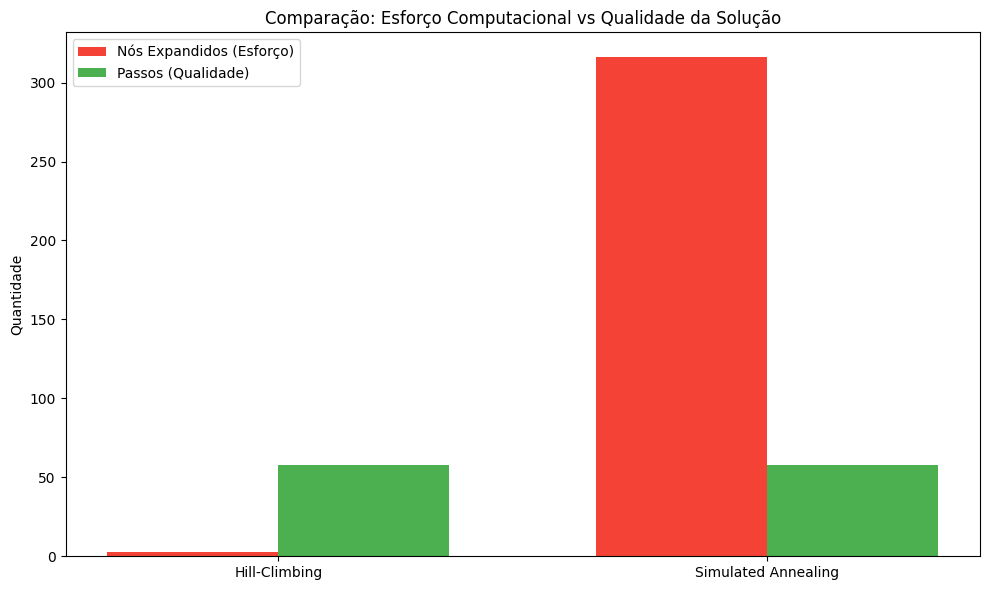

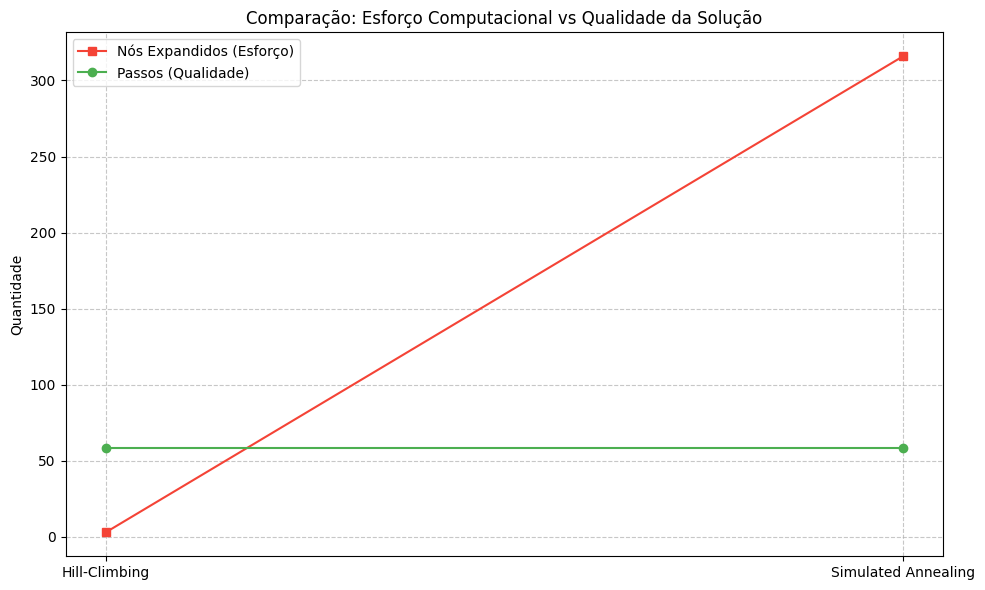

In [ ]:
import time
from pathlib import Path
import matplotlib.pyplot as plt

if 'NOME_ARQUIVO_LABIRINTO' not in globals() or not Path(NOME_ARQUIVO_LABIRINTO).exists():
    NOME_ARQUIVO_LABIRINTO = "labirintos/labTesteSanidadeMinima.txt"

try:
    lab = LabirintoBusca(NOME_ARQUIVO_LABIRINTO)
except ValueError as e:
    print(f"⚠️ Erro ao carregar '{NOME_ARQUIVO_LABIRINTO}': {e}")
    print("Ajustando temporariamente para o mapa oficial para não travar a execução...")
    NOME_ARQUIVO_LABIRINTO = "labirintos/labTesteSanidadeMinima.txt"
    lab = LabirintoBusca(NOME_ARQUIVO_LABIRINTO)

if len(lab.pontos_coleta) == 0:
    posicoes_livres = []
    for i in range(lab.altura):
        for j in range(lab.largura):
            if not lab.paredes[i][j] and (i, j) != lab.inicio and (i, j) != lab.objetivo:
                posicoes_livres.append((i, j))
    lab.pontos_coleta = posicoes_livres[:6]

print(f"Executando experimentos no mapa: {NOME_ARQUIVO_LABIRINTO}")
print(f"Total de pontos de coleta 'C' identificados: {len(lab.pontos_coleta)}")

if len(lab.pontos_coleta) == 0:
    print("⚠️ ATENÇÃO: O labirinto é muito pequeno ou não possui células livres suficientes.")
else:
    RODADAS = 30 
    vizinhanca = 'swap' 
    
    custos_hc, tempos_hc, iters_hc = [], [], []
    custos_sa, tempos_sa, iters_sa = [], [], []
    
    hist_exemplo_hc, hist_exemplo_sa = None, None
    melhor_seq_hc, melhor_seq_sa = None, None

    print("\nProcessando 30 execuções, por favor aguarde...")
    for _ in range(RODADAS):
        t_ini = time.perf_counter()
        r_hc, c_hc, h_hc, i_hc = lab.hill_climbing(tipo_vizinhanca=vizinhanca)
        tempos_hc.append(time.perf_counter() - t_ini)
        custos_hc.append(c_hc)
        iters_hc.append(i_hc)
        if hist_exemplo_hc is None or c_hc < min(custos_hc):
            hist_exemplo_hc = h_hc
            melhor_seq_hc = r_hc

        t_ini = time.perf_counter()
        r_sa, c_sa, h_sa, i_sa = lab.simulated_annealing(tipo_vizinhanca=vizinhanca)
        tempos_sa.append(time.perf_counter() - t_ini)
        custos_sa.append(c_sa)
        iters_sa.append(i_sa)
        if hist_exemplo_sa is None or c_sa < min(custos_sa):
            hist_exemplo_sa = h_sa
            melhor_seq_sa = r_sa

    custo_aceitavel = min(min(custos_hc), min(custos_sa))
    taxa_sucesso_hc = sum(1 for c in custos_hc if c <= custo_aceitavel) / RODADAS * 100
    taxa_sucesso_sa = sum(1 for c in custos_sa if c <= custo_aceitavel) / RODADAS * 100

    print("\n======================= MÉTRICAS OBRIGATÓRIAS =======================")
    print(f"Métrica                      | Hill-Climbing             | Simulated Annealing")
    print("-" * 83)
    print(f"Melhor Custo Encontrado      | {min(custos_hc):<25.1f} | {min(custos_sa):.1f}")
    print(f"Pior Custo Encontrado        | {max(custos_hc):<25.1f} | {max(custos_sa):.1f}")
    print(f"Custo Médio em {RODADAS} execs      | {(sum(custos_hc)/RODADAS):<25.1f} | {(sum(custos_sa)/RODADAS):.1f}")
    print(f"Tempo Médio de Execução (s)  | {(sum(tempos_hc)/RODADAS):<25.5f} | {(sum(tempos_sa)/RODADAS):.5f}")
    print(f"Número Médio de Iterações    | {(sum(iters_hc)/RODADAS):<25.1f} | {(sum(iters_sa)/RODADAS):.1f}")
    print(f"Taxa de Sucesso (Ótimo) (%)  | {taxa_sucesso_hc:<25.1f} | {taxa_sucesso_sa:.1f}")
    print("===================================================================================\n")
    
    print(f"Melhor ordem encontrada pelo Hill-Climbing: {melhor_seq_hc}")
    print(f"Melhor ordem encontrada pelo Simulated Annealing: {melhor_seq_sa}\n")
    

    print("Gerando Gráfico Obrigatório da Seção 6.5 (Evolução de Convergência)...")
    plotar_convergencia_busca_local(hist_exemplo_hc, hist_exemplo_sa)
    
   
    class ResultadoMétricasMédia:
        def __init__(self, algoritmo, encontrado, custo, expandidos):
            self.algoritmo = algoritmo
            self.encontrado = encontrado
            self.custo_caminho = custo
            self.tamanho_caminho = custo  
            self.nos_expandidos = expandidos  

    res_hc_media = ResultadoMétricasMédia("Hill-Climbing", True, sum(custos_hc)/RODADAS, sum(iters_hc)/RODADAS)
    res_sa_media = ResultadoMétricasMédia("Simulated Annealing", True, sum(custos_sa)/RODADAS, sum(iters_sa)/RODADAS)
    
    lista_bl_medias = [res_hc_media, res_sa_media]
    
    print("\nGerando gráficos comparativos paralelos do grupo (Barras e Linhas)...")
    plot_batch_comparison(lista_bl_medias)    
    plot_lines_comparison(lista_bl_medias)

## 6 Busca Online no Labirinto Desconhecido

Nesta etapa, o agente não conhece o labirinto completo.
O professor fornece ao simulador o mapa real, mas o agente não pode acessá-lo diretamente.
O agente deverá construir um mapa interno progressivamente.

### 6.1 Mapa Real e Mapa Interno

**Mapa real:** Contém todas as paredes, caminhos e objetivos. Ele é usado apenas pelo simulador.

**Mapa interno:** O mapa interno do agente começa desconhecido:
```
????????????
????????????
????A???????
????????????
????????????
```
Conforme o agente se move, ele percebe células próximas e atualiza seu modelo interno.

In [ ]:
class MapaInterno:
    def __init__(self, altura, largura, inicio, objetivo):
        self.altura = altura
        self.largura = largura
        self.inicio = inicio
        self.objetivo = objetivo
        self.grid = [['?' for _ in range(largura)] for _ in range(altura)]
        self.grid[inicio[0]][inicio[1]] = False  
        
    def atualizar_celula(self, estado, tem_parede):
        linha, coluna = estado
        if 0 <= linha < self.altura and 0 <= coluna < self.largura:
            self.grid[linha][coluna] = tem_parede
            
    def vizinhos_conhecidos(self, estado):
        linha, coluna = estado
        candidatos = [
            ('up',    (linha - 1, coluna)),
            ('down',  (linha + 1, coluna)),
            ('left',  (linha, coluna - 1)),
            ('right', (linha, coluna + 1)),
        ]
        resultado = []
        for acao, (l, c) in candidatos:
            if 0 <= l < self.altura and 0 <= c < self.largura:
                if self.grid[l][c] == False or self.grid[l][c] == '?':
                    resultado.append((acao, (l, c), 1.0))
        return resultado

    def imprimir(self, posicao_agente=None):
        linhas_str = ["\n--- Mapa Interno do Agente ---"]
        for i in range(self.altura):
            linha = []
            for j in range(self.largura):
                estado = (i, j)
                if posicao_agente and estado == posicao_agente:
                    linha.append('O')
                elif estado == self.inicio:
                    linha.append('A')
                elif estado == self.objetivo:
                    linha.append('B')
                elif self.grid[i][j] == '?':
                    linha.append('?')
                elif self.grid[i][j] == True:
                    linha.append('█')
                else:
                    linha.append(' ')
            linhas_str.append("".join(linha))
        linhas_str.append("------------------------------\n")
        print("\n".join(linhas_str))

class SimuladorReal:
    def __init__(self, labirinto: LabirintoBusca):
        self.labirinto = labirinto
        self.posicao_agente = labirinto.inicio
        
    def perceber_vizinhanca(self):
        linha, coluna = self.posicao_agente
        percepcoes = []
        candidatos = [
            (linha - 1, coluna),
            (linha + 1, coluna),
            (linha, coluna - 1),
            (linha, coluna + 1)
        ]
        for l, c in candidatos:
            if 0 <= l < self.labirinto.altura and 0 <= c < self.labirinto.largura:
                percepcoes.append(((l, c), self.labirinto.paredes[l][c]))
            else:
                percepcoes.append(((l, c), True)) 
        return percepcoes
    
    def mover_agente(self, nova_posicao):
        l, c = nova_posicao
        if 0 <= l < self.labirinto.altura and 0 <= c < self.labirinto.largura:
            if not self.labirinto.paredes[l][c]:
                self.posicao_agente = nova_posicao
                return True
        return False


### 6.2 Ciclo da Busca Online

A cada passo, o agente deverá executar o ciclo:

**perceber -> atualizar mapa interno -> planejar -> agir.**

Essa é a diferença central em relação à busca clássica:
- **busca clássica:** planejar com mapa completo
- **busca online:** descobrir o mapa enquanto age.

In [ ]:
class AgenteOnline:
    def __init__(self, inicio, objetivo, altura, largura):
        self.mapa_interno = MapaInterno(altura, largura, inicio, objetivo)
        self.posicao_atual = inicio
        self.objetivo = objetivo
        self.passos_dados = 0
        self.celulas_reveladas = set([inicio])
        self.celulas_revisitadas = 0
        self.replanejamentos = 0
        self.caminho_percorrido = [inicio]
        
    def perceber_e_atualizar(self, percepcoes):
        for estado, tem_parede in percepcoes:
            if self.mapa_interno.grid[estado[0]][estado[1]] == '?':
                self.celulas_reveladas.add(estado)
            self.mapa_interno.atualizar_celula(estado, tem_parede)
            
    def planejar(self):
        raise NotImplementedError
        
    def agir(self, proxima_posicao, simulador: SimuladorReal):
        if simulador.mover_agente(proxima_posicao):
            if proxima_posicao in self.caminho_percorrido:
                self.celulas_revisitadas += 1
            self.posicao_atual = proxima_posicao
            self.caminho_percorrido.append(proxima_posicao)
            self.passos_dados += 1
            return True
        return False

    def ciclo_online(self, simulador: SimuladorReal, log=False, animar=False, delay=0.1):
        from IPython.display import clear_output
        import time
        while self.posicao_atual != self.objetivo:
            percepcoes = simulador.perceber_vizinhanca()
            self.perceber_e_atualizar(percepcoes)
            
            if animar:
                clear_output(wait=True)
                print(f"Passos: {self.passos_dados} | Replanejamentos: {self.replanejamentos}")
                self.mapa_interno.imprimir(self.posicao_atual)
                time.sleep(delay)
            proxima_posicao = self.planejar()
            if proxima_posicao is None:
                if log: print("Falha: O agente não encontrou caminho no seu mapa interno.")
                return False
            sucesso_acao = self.agir(proxima_posicao, simulador)
            if not sucesso_acao:
                if log: print("Falha: O agente tentou mover para uma parede!")
                return False
                
        return True


### 6.3 Estratégias Possíveis

**Opção A – Replanning com A***
O agente mantém um mapa interno. A cada nova percepção, ele atualiza esse mapa e executa A* no mapa parcialmente conhecido.
O agente deve executar apenas o próximo passo e depois replanejar.

In [ ]:
import heapq
import itertools

class AgenteReplanningAStar(AgenteOnline):
    def h(self, estado):
        return abs(estado[0] - self.objetivo[0]) + abs(estado[1] - self.objetivo[1])

    def planejar(self):
        self.replanejamentos += 1
        inicio_busca = self.posicao_atual
        contador = itertools.count()
        
        fronteira = []
        heapq.heappush(fronteira, (self.h(inicio_busca), next(contador), inicio_busca, []))
        
        melhor_g = {inicio_busca: 0.0}
        
        while fronteira:
            f, _, atual, caminho = heapq.heappop(fronteira)
            
            if atual == self.objetivo:
                if len(caminho) > 0:
                    return caminho[0]
                return None
                
            for acao, vizinho, custo in self.mapa_interno.vizinhos_conhecidos(atual):
                novo_g = melhor_g[atual] + custo
                
                if vizinho not in melhor_g or novo_g < melhor_g[vizinho]:
                    melhor_g[vizinho] = novo_g
                    novo_caminho = list(caminho)
                    novo_caminho.append(vizinho)
                    f_score = novo_g + self.h(vizinho)
                    heapq.heappush(fronteira, (f_score, next(contador), vizinho, novo_caminho))
                    
        return None


### 6.4 Métricas Obrigatórias e Execução da Busca Online

Nesta célula, vamos instanciar o `SimuladorReal` com o labirinto carregado e rodar o `AgenteReplanningAStar`. Em seguida, exibiremos as métricas.

In [ ]:

try:
    labirinto_base = LabirintoBusca(NOME_ARQUIVO_LABIRINTO)
except NameError:
    print("Por favor, carregue o labirinto na seção 1 do notebook primeiro.")
else:
    resultado_offline = labirinto_base.busca_astar()
    custo_otimo = resultado_offline.custo_caminho if resultado_offline.encontrado else float('inf')
    
    simulador = SimuladorReal(labirinto_base)
    agente = AgenteReplanningAStar(labirinto_base.inicio, labirinto_base.objetivo, labirinto_base.altura, labirinto_base.largura)
    
    sucesso = agente.ciclo_online(simulador, log=True, animar=True, delay=0.1)
    
    custo_real = agente.passos_dados
    razao = custo_real / custo_otimo if custo_otimo > 0 else float('inf')
    
    print("=================== RESULTADOS DA BUSCA ONLINE ===================")
    print(f"Estratégia: Replanning com A*")
    print(f"Sucesso ou Falha: {'Sucesso' if sucesso else 'Falha'}")
    print(f"Número total de movimentos: {agente.passos_dados}")
    print(f"Custo real percorrido: {custo_real}")
    print(f"Número de células reveladas: {len(agente.celulas_reveladas)}")
    print(f"Número de células revisitadas: {agente.celulas_revisitadas}")
    print(f"Número de replanejamentos: {agente.replanejamentos}")
    print(f"Custo ótimo offline: {custo_otimo}")
    print(f"RAZÃO ONLINE/OFFLINE: {razao:.2f}")
    print("==================================================================")
    
    agente.mapa_interno.imprimir()
    
    print("\nPara ver o caminho detalhado que ele fez, o vetor de posições é:")
    print(agente.caminho_percorrido)


### 6.5 Gráfico de Desempenho da Busca Online

Gera o gráfico comparativo do Esforço vs Qualidade da solução online.

In [ ]:
import matplotlib.pyplot as plt

def plot_online_metrics(agente, custo_otimo):
    nomes_metricas = ['Passos (Real)', 'Custo Ótimo', 'Reveladas', 'Replan.']
    valores_metricas = [
        agente.passos_dados,
        custo_otimo if custo_otimo != float('inf') else 0,
        len(agente.celulas_reveladas),
        agente.replanejamentos
    ]
    
    plt.figure(figsize=(8, 5))
    cores = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
    barras = plt.bar(nomes_metricas, valores_metricas, color=cores)
    
    plt.title('Métricas de Desempenho: Busca Online')
    plt.ylabel('Quantidade')
    
    for barra in barras:
        valor = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, valor + (max(valores_metricas)*0.02), 
                 str(int(valor)), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_online_metrics_lines(agente, custo_otimo):
    nomes_metricas = ['Passos (Real)', 'Custo Ótimo', 'Reveladas', 'Replan.']
    valores_metricas = [
        agente.passos_dados,
        custo_otimo if custo_otimo != float('inf') else 0,
        len(agente.celulas_reveladas),
        agente.replanejamentos
    ]
    
    plt.figure(figsize=(8, 5))
    plt.plot(nomes_metricas, valores_metricas, marker='o', linestyle='-', color='#2196F3', linewidth=2)
    
    plt.title('Métricas de Desempenho: Busca Online (Linhas)')
    plt.ylabel('Quantidade')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    for i, v in enumerate(valores_metricas):
        plt.text(i, v + (max(valores_metricas)*0.02), str(int(v)), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

try:
    plot_online_metrics(agente, custo_otimo)
    plot_online_metrics_lines(agente, custo_otimo)
except NameError:
    print("Execute a célula de busca online primeiro para gerar os dados do agente.")
